# Calibration Testing

Self-contained notebook in `calibration_testing/`:
1. Intrinsic calibration and intrinsic reprojection error
2. Undistort `source.png` / `sink.png` (for visualization)
3. Load JSON: **`image_points` are always in distorted / raw pixel space**; Step 3 undistorts them only for overlay on the undistorted image
4. Extrinsic solve in **distorted / raw** image space (`camera_matrix` + `dist_coeffs` from Step 1)


In [ ]:
import os
import json
from datetime import datetime

import cv2
import yaml
import pickle
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath('.')
if os.path.basename(ROOT) == 'calibration_testing':
    BASE_DIR = ROOT
else:
    BASE_DIR = os.path.join(ROOT, 'calibration_testing')

# ---------- Top-level config ----------
MODE = 'sink'  # change to 'sink' when needed
assert MODE in ('source', 'sink')

if MODE == 'source':
    CB_DIR = os.path.join(BASE_DIR, 'merged_frames')
else:
    CB_DIR = os.path.join(BASE_DIR, 'chessboard_images_2.8mm')

TARGET_DIR = os.path.join(BASE_DIR, MODE)

IMAGE_NAME = f'{MODE}.png'
SOURCE_IMAGE = os.path.join(TARGET_DIR, IMAGE_NAME)
COURT_INFO = os.path.join(TARGET_DIR, 'court_info.json')

CAM_YAML = os.path.join(TARGET_DIR, 'camera_object.yaml')
CAM_PKL = os.path.join(TARGET_DIR, 'camera_object.pkl')
INTRINSIC_EVAL_JSON = os.path.join(TARGET_DIR, 'intrinsic_eval.json')
UNDISTORTED_IMAGE = os.path.join(TARGET_DIR, f'{MODE}_undistorted_new.png')
POINTS_PLOT_IMAGE = os.path.join(TARGET_DIR, f'{MODE}_points_on_undistorted.png')
EXTRINSIC_JSON = os.path.join(TARGET_DIR, 'extrinsic_pose_undistorted.json')
EXTRINSIC_OVERLAY = os.path.join(TARGET_DIR, f'{MODE}_extrinsic_reprojection_overlay.png')

os.makedirs(TARGET_DIR, exist_ok=True)
assert os.path.exists(CB_DIR), f'Missing checkeSOURCE_IMAGErboard dir: {CB_DIR}'
assert os.path.exists(SOURCE_IMAGE), f'Missing source image: {SOURCE_IMAGE}'
assert os.path.exists(COURT_INFO), f'Missing court json: {COURT_INFO}'

print('BASE_DIR:', BASE_DIR)
print('MODE:', MODE)
print('TARGET_DIR:', TARGET_DIR)
print('SOURCE_IMAGE:', SOURCE_IMAGE)
print('COURT_INFO:', COURT_INFO)



BASE_DIR: /home/ubuntu/test_work/judex-web/calibration_testing
MODE: sink
TARGET_DIR: /home/ubuntu/test_work/judex-web/calibration_testing/sink
SOURCE_IMAGE: /home/ubuntu/test_work/judex-web/calibration_testing/sink/sink.png
COURT_INFO: /home/ubuntu/test_work/judex-web/calibration_testing/sink/court_info.json


## Step 1: Intrinsic Calibration + Error


In [46]:
# Chessboard settings (same pattern used in your scripts)
CH_DIM = (6, 8)  # rows, cols in your current setup
SQ_SIZE_MM = 25.0
MIN_IMAGES = 3
IS_FISHEYE = False

obj_3d = np.zeros((CH_DIM[0] * CH_DIM[1], 3), np.float32)
idx = 0
for i in range(CH_DIM[0]):
    for j in range(CH_DIM[1]):
        obj_3d[idx][0] = i * SQ_SIZE_MM
        obj_3d[idx][1] = j * SQ_SIZE_MM
        idx += 1

ch_dim_cv = (CH_DIM[1], CH_DIM[0])
images = sorted([f for f in os.listdir(CB_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
assert images, 'No checkerboard images found.'

objpoints, imgpoints = [], []
ref_shape = None
corner_dir = os.path.join(TARGET_DIR, 'corner_images')
os.makedirs(corner_dir, exist_ok=True)

for name in images:
    p = os.path.join(CB_DIR, name)
    im = cv2.imread(p)
    if im is None:
        continue
    if ref_shape is None:
        ref_shape = im.shape[:2][::-1]  # width,height
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, ch_dim_cv, None)
    vis = im.copy()
    if ret:
        cv2.drawChessboardCorners(vis, ch_dim_cv, corners, ret)
        corners2 = cv2.cornerSubPix(
            gray,
            corners,
            (3, 3),
            (-1, -1),
            (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001),
        )
        objpoints.append(obj_3d)
        imgpoints.append(corners2)
    cv2.imwrite(os.path.join(corner_dir, name), vis)

assert len(objpoints) >= MIN_IMAGES, f'Need {MIN_IMAGES}+ detections, found {len(objpoints)}'

if IS_FISHEYE:
    K = np.zeros((3, 3))
    D = np.zeros((4, 1))
    objp = [np.asarray(pts, dtype=np.float32).reshape(-1, 1, 3) for pts in objpoints]
    imgp = [np.asarray(pts, dtype=np.float32).reshape(-1, 1, 2) for pts in imgpoints]
    flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_CHECK_COND + cv2.fisheye.CALIB_FIX_SKEW
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.fisheye.calibrate(
        objp, imgp, ref_shape, K, D, None, None, flags,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6)
    )
    calib_type = 'fisheye'
else:
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, ref_shape, None, None)
    calib_type = 'pinhole'

# Per-image reprojection error
per_image_errors = []
for i in range(len(objpoints)):
    proj, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], camera_matrix, dist_coeffs)
    err = np.sqrt(np.mean((imgpoints[i].reshape(-1, 2) - proj.reshape(-1, 2)) ** 2))
    per_image_errors.append(float(err))

intrinsic_eval = {
    'timestamp': datetime.now().isoformat(),
    'num_detected_images': len(objpoints),
    'opencv_rms': float(ret),
    'per_image_rmse': per_image_errors,
    'camera_matrix': camera_matrix.tolist(),
    'dist_coeffs': dist_coeffs.tolist(),
    'image_size': list(ref_shape),
    'calibration_type': calib_type,
}

with open(INTRINSIC_EVAL_JSON, 'w', encoding='utf-8') as f:
    json.dump(intrinsic_eval, f, indent=2)

cam_obj = {
    'camera_matrix': camera_matrix.tolist(),
    'dist_coeffs': dist_coeffs.tolist(),
    'image_size': list(ref_shape),
    'reprojection_error': float(ret),
    'calibration_type': calib_type,
    'rvecs': [r.tolist() for r in rvecs],
    'tvecs': [t.tolist() for t in tvecs],
    'date': datetime.now().isoformat(),
}
with open(CAM_YAML, 'w', encoding='utf-8') as f:
    yaml.safe_dump(cam_obj, f, sort_keys=False)
with open(CAM_PKL, 'wb') as f:
    pickle.dump(cam_obj, f)

print('Detected images:', len(objpoints))
print('OpenCV intrinsic RMS:', float(ret))
print('Per-image RMSE mean:', float(np.mean(per_image_errors)))
print('Saved:', CAM_YAML)
print('Saved:', INTRINSIC_EVAL_JSON)



Detected images: 216
OpenCV intrinsic RMS: 1.0303291368796215
Per-image RMSE mean: 0.5166748592423068
Saved: /home/ubuntu/test_work/judex-web/calibration_testing/sink/camera_object.yaml
Saved: /home/ubuntu/test_work/judex-web/calibration_testing/sink/intrinsic_eval.json


## Step 2: Undistort source image


Saved: /home/ubuntu/test_work/judex-web/calibration_testing/sink/sink_undistorted_new.png
Undistorted shape: (1080, 1440, 3)


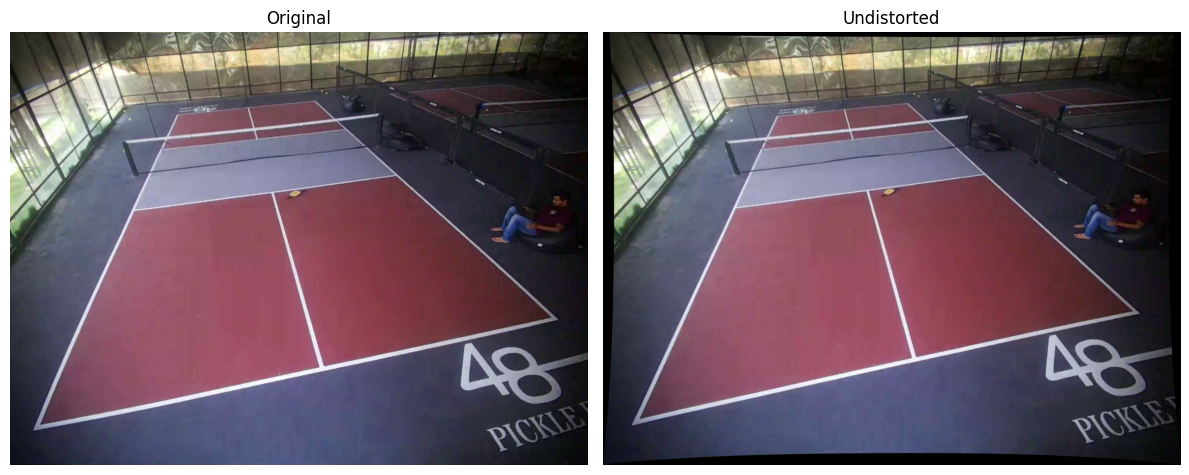

In [47]:
img = cv2.imread(SOURCE_IMAGE)
assert img is not None, f'Could not read {SOURCE_IMAGE}'
h, w = img.shape[:2]

if calib_type == 'fisheye':
    new_camera_matrix = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        camera_matrix, dist_coeffs, (w, h), np.eye(3), balance=1.0
    )
    undistorted = cv2.fisheye.undistortImage(
        img, camera_matrix, dist_coeffs, Knew=new_camera_matrix
    )
else:
    new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
        camera_matrix, dist_coeffs, (w, h), 1.0, (w, h)
    )
    undistorted = cv2.undistort(img, camera_matrix, dist_coeffs, None, new_camera_matrix)


cv2.imwrite(UNDISTORTED_IMAGE, undistorted)
print('Saved:', UNDISTORTED_IMAGE)
print('Undistorted shape:', undistorted.shape)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.title('Original'); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(1,2,2); plt.title('Undistorted'); plt.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.tight_layout()


## Step 3: Plot JSON points (undistorted space, visualization only)

If `court_info.json` has `image_points_space: "distorted"`, points are converted with `cv2.undistortPoints(..., P=new_camera_matrix)` for plotting. **Step 4** uses distorted clicks + `camera_matrix` + `dist_coeffs`.


distorted JSON -> undistorted pixels (new_camera_matrix) for overlay only
Saved distorted-space plot: /home/ubuntu/test_work/judex-web/calibration_testing/sink/sink_points_on_distorted.png
Loaded points: 10
Saved: /home/ubuntu/test_work/judex-web/calibration_testing/sink/sink_points_on_undistorted.png


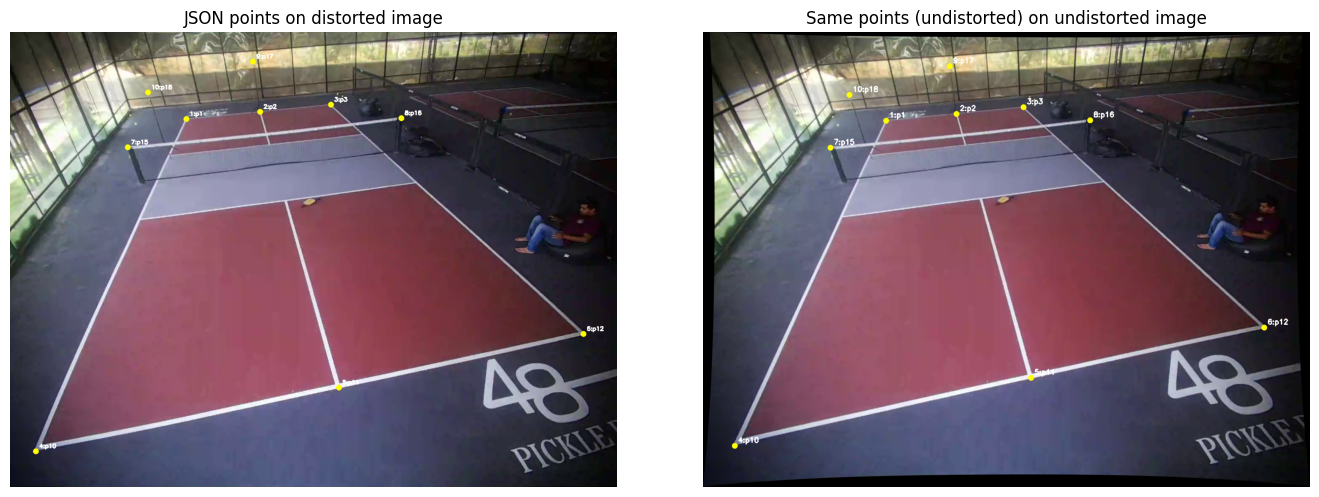

In [50]:
with open(COURT_INFO, 'r', encoding='utf-8') as f:
    court_info = json.load(f)

world_points = np.asarray(court_info['world_points'], dtype=np.float32)
image_points_distorted = np.asarray(court_info['image_points'], dtype=np.float32)
point_names = court_info.get('point_names', [f'p{i+1}' for i in range(len(image_points_distorted))])
# JSON clicks are always treated as distorted raw pixels; keep for extrinsic + plots
space = court_info.get('image_points_space', 'distorted')

assert len(world_points) == len(image_points_distorted), 'world/image point count mismatch'

# Undistort only for overlay on the undistorted image (Step 3 right panel)
pts_in = image_points_distorted.reshape(-1, 1, 2).astype(np.float32)
image_points = cv2.undistortPoints(
    pts_in, camera_matrix, dist_coeffs, P=new_camera_matrix
).reshape(-1, 2).astype(np.float32)
print('distorted JSON -> undistorted pixels (new_camera_matrix) for overlay only')

# Optional: show distorted clicks on raw image
vis_raw = img.copy()
for i, (pt, name) in enumerate(zip(image_points_distorted, point_names), start=1):
    x, y = int(round(float(pt[0]))), int(round(float(pt[1])))
    cv2.circle(vis_raw, (x, y), 7, (0, 255, 255), -1)
    cv2.putText(vis_raw, f'{i}:{name}', (x+8, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 2)
raw_plot_path = os.path.join(TARGET_DIR, f'{MODE}_points_on_distorted.png')
cv2.imwrite(raw_plot_path, vis_raw)
print('Saved distorted-space plot:', raw_plot_path)

vis = undistorted.copy()
for i, (pt, name) in enumerate(zip(image_points, point_names), start=1):
    x, y = int(round(float(pt[0]))), int(round(float(pt[1])))
    cv2.circle(vis, (x, y), 7, (0, 255, 255), -1)
    cv2.putText(vis, f'{i}:{name}', (x+8, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)

cv2.imwrite(POINTS_PLOT_IMAGE, vis)
print('Loaded points:', len(image_points))
print('Saved:', POINTS_PLOT_IMAGE)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.title('JSON points on distorted image')
plt.imshow(cv2.cvtColor(vis_raw, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Same points (undistorted) on undistorted image')
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()


## Step 4: Extrinsic solve + reprojection (distorted / raw image space)

Uses **original** `camera_matrix` + `dist_coeffs` and **distorted** JSON clicks. Step 3 undistorted plots are for visualization only.



=== world_points.txt: 3D (m) -> 2D px ===
  p1  world_m=(0.0000,0.0000,0.0000)  distorted_px=(414.68,208.08)  undistorted_newK_px=(431.29,211.80)
  p2  world_m=(3.0480,0.0000,0.0000)  distorted_px=(579.28,189.07)  undistorted_newK_px=(587.92,193.75)
  p3  world_m=(6.0960,0.0000,0.0000)  distorted_px=(738.67,170.28)  undistorted_newK_px=(738.99,176.33)
  p4  world_m=(0.0000,4.5750,0.0000)  distorted_px=(376.58,289.96)  undistorted_newK_px=(394.91,290.01)
  p5  world_m=(3.0480,4.5750,0.0000)  distorted_px=(599.68,262.58)  undistorted_newK_px=(607.38,263.72)
  p6  world_m=(6.0960,4.5750,0.0000)  distorted_px=(813.26,235.60)  undistorted_newK_px=(809.73,238.67)
  p7  world_m=(0.0000,8.8350,0.0000)  distorted_px=(304.25,445.25)  undistorted_newK_px=(325.64,438.89)
  p8  world_m=(3.0480,8.8350,0.0000)  distorted_px=(637.78,399.28)  undistorted_newK_px=(643.74,394.44)
  p9  world_m=(6.0960,8.8350,0.0000)  distorted_px=(950.75,355.20)  undistorted_newK_px=(939.59,353.10)
  p10  world_m=(0.000

(np.float64(-0.5), np.float64(1439.5), np.float64(1079.5), np.float64(-0.5))

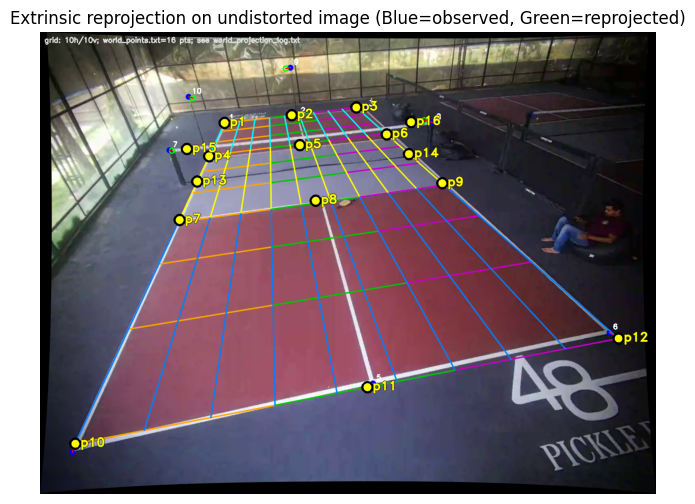

In [51]:
# Distorted / raw image space: original K + dist_coeffs (matches court_info distorted clicks)
K_ext = camera_matrix.astype(np.float64)
d_ext = dist_coeffs.astype(np.float64).reshape(-1, 1)

pts_for_pnp = image_points_distorted.astype(np.float64)
world_np = np.asarray(world_points, dtype=np.float64)

WORLD_POINTS_TXT = os.path.join(TARGET_DIR, 'world_points.txt')


def _parse_world_points_txt(path):
    rows = []
    names = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            line = line.split('#')[0].strip()
            parts = line.replace(',', ' ').split()
            if len(parts) < 3:
                continue
            try:
                float(parts[0])
                x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
                name = f'p{len(rows) + 1}'
            except ValueError:
                if len(parts) < 4:
                    continue
                name = parts[0]
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            rows.append([x, y, z])
            names.append(name)
    return np.asarray(rows, dtype=np.float64), names


_wp_txt, _names_txt = None, None
if os.path.isfile(WORLD_POINTS_TXT):
    _wp_txt, _names_txt = _parse_world_points_txt(WORLD_POINTS_TXT)
    if len(_wp_txt) == 0:
        _wp_txt, _names_txt = None, None

# Hold out 1-based "point 7" and "point 8" = JSON array indices 6 and 7 (p15, p16 with current court_info).
# Set to [] to use all points for extrinsic (no holdout validation).
EXTRINSIC_HOLDOUT_INDICES = []

_n = len(world_np)
_hold = set(int(i) for i in EXTRINSIC_HOLDOUT_INDICES)
_train_mask = np.array([i not in _hold for i in range(_n)], dtype=bool)
assert _train_mask.sum() >= 4, 'Need at least 4 points for solvePnP after holdout'
world_train = world_np[_train_mask]
pts_train = pts_for_pnp[_train_mask]

ok, rvec, tvec = cv2.solvePnP(
    world_train,
    pts_train,
    K_ext,
    d_ext,
    useExtrinsicGuess=False,
    flags=cv2.SOLVEPNP_ITERATIVE,
)
assert ok, 'solvePnP failed'

rvec, tvec = cv2.solvePnPRefineVVS(
    world_train,
    pts_train,
    K_ext,
    d_ext,
    rvec,
    tvec,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 100, 0.01),
)

reproj, _ = cv2.projectPoints(world_np, rvec, tvec, K_ext, d_ext)
reproj = reproj.reshape(-1, 2)

diffs = pts_for_pnp - reproj
per_point_err = np.linalg.norm(diffs, axis=1)
diffs_train = diffs[_train_mask]
rmse_train = float(np.sqrt(np.mean(np.sum(diffs_train ** 2, axis=1))))
mean_err_train = float(np.mean(per_point_err[_train_mask]))
if len(_hold):
    diffs_hold = diffs[~_train_mask]
    rmse_holdout = float(np.sqrt(np.mean(np.sum(diffs_hold ** 2, axis=1))))
    mean_err_holdout = float(np.mean(per_point_err[~_train_mask]))
    holdout_detail = [
        {'index': int(i), 'name': point_names[i], 'error_px': float(per_point_err[i])}
        for i in sorted(_hold)
    ]
else:
    rmse_holdout = None
    mean_err_holdout = None
    holdout_detail = []

rmse_all = float(np.sqrt(np.mean(np.sum(diffs ** 2, axis=1))))
mean_err = float(np.mean(per_point_err))

result = {
    'timestamp': datetime.now().isoformat(),
    'num_points': int(len(world_np)),
    'num_points_used_for_extrinsic': int(_train_mask.sum()),
    'extrinsic_holdout_indices': list(sorted(_hold)),
    'image_points_space': space,
    'solve_space': 'distorted',
    'rmse_px': rmse_train,
    'mean_error_px': mean_err_train,
    'rmse_px_all_points': rmse_all,
    'mean_error_px_all_points': mean_err,
    'rmse_px_holdout': rmse_holdout,
    'mean_error_px_holdout': mean_err_holdout,
    'holdout_validation': holdout_detail,
    'per_point_error_px': [float(x) for x in per_point_err],
    'rvec': rvec.flatten().tolist(),
    'tvec': tvec.flatten().tolist(),
    'camera_matrix_used': K_ext.tolist(),
    'dist_coeffs_used': d_ext.flatten().tolist(),
}
extrinsic_result = result
with open(EXTRINSIC_JSON, 'w', encoding='utf-8') as f:
    json.dump(result, f, indent=2)

# Overlay on undistorted image (same new_camera_matrix + mapping as Step 2)
h_img, w_img = img.shape[:2]
if calib_type == 'fisheye':
    D_fe = dist_coeffs.astype(np.float64).reshape(4, 1)
    newK_overlay = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        K_ext, D_fe, (w_img, h_img), np.eye(3), balance=1.0
    )
    overlay = cv2.fisheye.undistortImage(img, K_ext, D_fe, Knew=newK_overlay)

    def _pixels_to_undist(uv_d):
        u = cv2.fisheye.undistortPoints(
            uv_d.reshape(-1, 1, 2).astype(np.float64), K_ext, D_fe, P=newK_overlay
        )
        return u.reshape(-1, 2)
else:
    newK_overlay, _ = cv2.getOptimalNewCameraMatrix(
        K_ext, d_ext, (w_img, h_img), 1.0, (w_img, h_img)
    )
    overlay = cv2.undistort(img, K_ext, d_ext, None, newK_overlay)

    def _pixels_to_undist(uv_d):
        return cv2.undistortPoints(
            uv_d.reshape(-1, 1, 2).astype(np.float64), K_ext, d_ext, P=newK_overlay
        ).reshape(-1, 2)

obs_u = _pixels_to_undist(pts_for_pnp)
reproj_u = _pixels_to_undist(reproj)

for i, (obs, pred) in enumerate(zip(obs_u, reproj_u), start=1):
    ox, oy = int(round(float(obs[0]))), int(round(float(obs[1])))
    px, py = int(round(float(pred[0]))), int(round(float(pred[1])))
    cv2.circle(overlay, (ox, oy), 7, (255, 0, 0), -1)
    cv2.circle(overlay, (px, py), 6, (0, 255, 0), 2)
    cv2.line(overlay, (ox, oy), (px, py), (0, 0, 255), 2)
    cv2.putText(overlay, f'{i}', (ox + 8, oy - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)

# World grid (ground z=0): horizontals = fixed y, x in L/M/R thirds; verticals = fixed x, y in B/M/T thirds
if _wp_txt is not None:
    _wp = _wp_txt
else:
    _wp = np.asarray(world_points, dtype=np.float64)
_xmin, _xmax = float(_wp[:, 0].min()), float(_wp[:, 0].max())
_ymin, _ymax = float(_wp[:, 1].min()), float(_wp[:, 1].max())
_zg = 0.0
_n_lines = 10
_xa, _xb = _xmin, _xmin + (_xmax - _xmin) / 3.0
_xb2 = _xmin + 2.0 * (_xmax - _xmin) / 3.0
_xc = _xmax
_ya, _yb = _ymin, _ymin + (_ymax - _ymin) / 3.0
_yb2 = _ymin + 2.0 * (_ymax - _ymin) / 3.0
_yc = _ymax
_h_colors = ((0, 165, 255), (0, 200, 0), (200, 0, 200))  # L/M/R along x (BGR)
_v_colors = ((255, 255, 0), (0, 255, 255), (255, 128, 0))  # B/M/T along y: yellow / cyan / orange (BGR)

for _y in np.linspace(_ymin, _ymax, _n_lines):
    _seg = np.array(
        [
            [[_xa, _y, _zg], [_xb, _y, _zg]],
            [[_xb, _y, _zg], [_xb2, _y, _zg]],
            [[_xb2, _y, _zg], [_xc, _y, _zg]],
        ],
        dtype=np.float64,
    )
    _proj_d, _ = cv2.projectPoints(_seg.reshape(-1, 1, 3), rvec, tvec, K_ext, d_ext)
    _proj_u = _pixels_to_undist(_proj_d.reshape(-1, 2))
    _proj_u = _proj_u.reshape(3, 2, 2)
    for _k in range(3):
        _p0 = (int(round(float(_proj_u[_k, 0, 0]))), int(round(float(_proj_u[_k, 0, 1]))))
        _p1 = (int(round(float(_proj_u[_k, 1, 0]))), int(round(float(_proj_u[_k, 1, 1]))))
        cv2.line(overlay, _p0, _p1, _h_colors[_k], 2, cv2.LINE_AA)

for _x in np.linspace(_xmin, _xmax, _n_lines):
    _seg = np.array(
        [
            [[_x, _ya, _zg], [_x, _yb, _zg]],
            [[_x, _yb, _zg], [_x, _yb2, _zg]],
            [[_x, _yb2, _zg], [_x, _yc, _zg]],
        ],
        dtype=np.float64,
    )
    _proj_d, _ = cv2.projectPoints(_seg.reshape(-1, 1, 3), rvec, tvec, K_ext, d_ext)
    _proj_u = _pixels_to_undist(_proj_d.reshape(-1, 2))
    _proj_u = _proj_u.reshape(3, 2, 2)
    for _k in range(3):
        _p0 = (int(round(float(_proj_u[_k, 0, 0]))), int(round(float(_proj_u[_k, 0, 1]))))
        _p1 = (int(round(float(_proj_u[_k, 1, 0]))), int(round(float(_proj_u[_k, 1, 1]))))
        cv2.line(overlay, _p0, _p1, _v_colors[_k], 2, cv2.LINE_AA)

# Direct 3D->2D: world_points.txt only (not court_info.json world_points for this overlay)
_hdr = '# distorted = raw source.png; undistorted_newK = this overlay PNG. Same rvec,tvec as extrinsic.\n'
_proj_log = [_hdr, '## world_points.txt (all points)', '']
if _wp_txt is None or len(_wp_txt) == 0:
    print('\n=== world_points.txt: missing or empty — skip 3D overlay log/draw ===')
else:
    print('\n=== world_points.txt: 3D (m) -> 2D px ===')
    _pdc, _ = cv2.projectPoints(_wp_txt.reshape(-1, 1, 3), rvec, tvec, K_ext, d_ext)
    _pdc = _pdc.reshape(-1, 2)
    _puc = _pixels_to_undist(_pdc)
    for _ci in range(len(_wp_txt)):
        _wx, _wy, _wz = float(_wp_txt[_ci, 0]), float(_wp_txt[_ci, 1]), float(_wp_txt[_ci, 2])
        _ud, _vd = float(_pdc[_ci, 0]), float(_pdc[_ci, 1])
        _uu, _vu = float(_puc[_ci, 0]), float(_puc[_ci, 1])
        _nm = str(_names_txt[_ci])
        _row = (
            f'{_nm}  world_m=({_wx:.4f},{_wy:.4f},{_wz:.4f})  '
            f'distorted_px=({_ud:.2f},{_vd:.2f})  undistorted_newK_px=({_uu:.2f},{_vu:.2f})'
        )
        print(' ', _row)
        _proj_log.append(_row)
    _wpt_fill = (0, 255, 255)
    _wpt_edge = (0, 0, 0)
    _wpt_font = cv2.FONT_HERSHEY_DUPLEX
    _wpt_scale = 0.95
    _wpt_th = 2
    for _ci in range(len(_puc)):
        _ux, _uy = float(_puc[_ci, 0]), float(_puc[_ci, 1])
        _ix, _iy = int(round(_ux)), int(round(_uy))
        cv2.circle(overlay, (_ix, _iy), 12, _wpt_edge, 3)
        cv2.circle(overlay, (_ix, _iy), 9, _wpt_fill, -1)
        _lbl = str(_names_txt[_ci])
        _tx, _ty = _ix + 12, _iy + 6
        cv2.putText(overlay, _lbl, (_tx, _ty), _wpt_font, _wpt_scale, _wpt_edge, _wpt_th + 2, cv2.LINE_AA)
        cv2.putText(overlay, _lbl, (_tx, _ty), _wpt_font, _wpt_scale, _wpt_fill, _wpt_th, cv2.LINE_AA)

_wproj_path = os.path.join(TARGET_DIR, 'world_projection_log.txt')
with open(_wproj_path, 'w', encoding='utf-8') as _wlf:
    _wlf.write('\n'.join(_proj_log) + '\n')
print('Saved:', _wproj_path)

cv2.putText(
    overlay,
    f'grid: 10h/10v; world_points.txt={len(_wp_txt) if _wp_txt is not None else 0} pts; see world_projection_log.txt',
    (10, 24),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.55,
    (220, 220, 220),
    2,
)

cv2.imwrite(EXTRINSIC_OVERLAY, overlay)

print('Extrinsic RMSE train (px, distorted space, points used in solvePnP):', rmse_train)
print('Extrinsic mean per-point train (px):', mean_err_train)
if rmse_holdout is not None:
    print('Extrinsic RMSE holdout (px, validation — not used in solvePnP):', rmse_holdout)
    print('Extrinsic mean per-point holdout (px):', mean_err_holdout)
    print('Holdout detail:', holdout_detail)
print('Extrinsic RMSE all points (px, for reference):', rmse_all)
for i, e in enumerate(per_point_err, start=1):
    tag = ' [holdout]' if (i - 1) in _hold else ''
    print(f'Point {i}{tag}: {float(e):.4f} px')
print('Saved:', EXTRINSIC_JSON)
print('Saved:', EXTRINSIC_OVERLAY)

plt.figure(figsize=(10, 6))
plt.title('Extrinsic reprojection on undistorted image (Blue=observed, Green=reprojected)')
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
